<div style="background:linear-gradient(135deg,#172554 0%,#1e40af 55%,#3b82f6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bfdbfe;font-weight:700;text-transform:uppercase">Chapter 71 · Estimation &amp; Confidence Intervals</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">CIs for Proportions &amp; Differences 🅰️🅱️</div>
  <div style="font-size:15px;color:#eff6ff;max-width:740px;line-height:1.6">Polls and A/B tests estimate proportions, and the interesting question is usually a DIFFERENCE. We build CIs for one proportion, for a difference of two proportions, and of two means, then settle a real A/B test from a spreadsheet.</div>
  <div style="margin-top:16px;font-size:13px;color:#bfdbfe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
BLUE="#2563eb"; DEEP="#1d4ed8"; LIGHT="#60a5fa"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
z = stats.norm.ppf(0.975)
rng = np.random.default_rng(71)

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 · CI FOR ONE PROPORTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">p-hat plus or minus a margin</div>
<div style="color:#4a5578;margin-top:6px">For a yes/no outcome, the proportion p-hat = successes/n estimates the true rate p. Its CI is p-hat +/- z*sqrt(p-hat(1-p-hat)/n), valid when there are at least ~10 successes AND ~10 failures (the success-failure condition).</div>
</div>

In [2]:
successes, n = 84, 500
phat = successes/n
se = np.sqrt(phat*(1-phat)/n)
lo, hi = phat - z*se, phat + z*se
print(f"p-hat = {successes}/{n} = {phat:.3f}, SE = {se:.4f}")
print(f"95% CI for the proportion: [{lo:.3f}, {hi:.3f}]  = {phat*100:.1f}% +/- {z*se*100:.1f} pts")
print(f"success-failure check: {successes} successes, {n-successes} failures (both >= 10? {successes>=10 and n-successes>=10})")

p-hat = 84/500 = 0.168, SE = 0.0167
95% CI for the proportion: [0.135, 0.201]  = 16.8% +/- 3.3 pts
success-failure check: 84 successes, 416 failures (both >= 10? True)


The proportion is <strong>16.8%</strong> with a 95% interval of about <strong>[13.5%, 20.1%]</strong>. The success-failure condition (&#8805;10 of each) is what lets us use the normal approximation; with very few successes, prefer the Wilson or exact interval instead.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 2 · CI FOR A DIFFERENCE OF PROPORTIONS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does group B beat group A?</div>
<div style="color:#4a5578;margin-top:6px">The real question in an experiment is the DIFFERENCE pB - pA. Its standard error combines both groups: SE = sqrt(pA(1-pA)/nA + pB(1-pB)/nB). If the CI for the difference excludes 0, the groups differ.</div>
</div>

In [3]:
pA, nA = 0.12, 800
pB, nB = 0.155, 820
diff = pB - pA
se = np.sqrt(pA*(1-pA)/nA + pB*(1-pB)/nB)
lo, hi = diff - z*se, diff + z*se
print(f"pA = {pA:.3f}, pB = {pB:.3f}, difference pB-pA = {diff:+.3f}")
print(f"SE of difference = {se:.4f}")
print(f"95% CI for (pB - pA): [{lo:+.3f}, {hi:+.3f}]")
print("-> excludes 0: the difference is statistically distinguishable from zero" if lo>0 or hi<0 else "-> includes 0: cannot rule out no difference")

pA = 0.120, pB = 0.155, difference pB-pA = +0.035
SE of difference = 0.0171
95% CI for (pB - pA): [+0.002, +0.068]
-> excludes 0: the difference is statistically distinguishable from zero


Because the interval for the difference lies entirely above 0, B&#39;s higher rate is unlikely to be a fluke. This is the engine of A/B testing: build a CI for the lift, and act if it clears 0.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 3 · CI FOR A DIFFERENCE OF MEANS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The same idea for numeric outcomes</div>
<div style="color:#4a5578;margin-top:6px">When the outcome is numeric (revenue per user, time on site), compare two means with a two-sample t-interval: (xB - xA) +/- t* sqrt(sA^2/nA + sB^2/nB).</div>
</div>

In [4]:
a = rng.normal(52, 14, 240)   # group A spend
b = rng.normal(56, 15, 260)   # group B spend
diff = b.mean() - a.mean()
se = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
dfw = (se**4) / ((a.var(ddof=1)/len(a))**2/(len(a)-1) + (b.var(ddof=1)/len(b))**2/(len(b)-1))  # Welch df
tcrit = stats.t.ppf(0.975, dfw)
print(f"mean A = {a.mean():.2f}, mean B = {b.mean():.2f}, difference = {diff:+.2f}")
print(f"95% CI for (meanB - meanA): [{diff-tcrit*se:+.2f}, {diff+tcrit*se:+.2f}]  (Welch df={dfw:.0f})")

mean A = 51.07, mean B = 56.16, difference = +5.09
95% CI for (meanB - meanA): [+2.80, +7.38]  (Welch df=494)


Same logic, numeric flavor: the two-sample t-interval estimates the gap between group means and its uncertainty. Whether the CI excludes 0 tells you if the difference is real.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · A/B TEST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A control vs a new landing page</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A product team ran a randomized A/B test and exported <strong>2,000 visitors</strong> (`ch71_ab_test.xlsx`): variant A is the control, B is a new design. We estimate each conversion rate with a CI, then build the CI for the lift.

In [5]:
try:    ab = pd.read_excel("../../data/ch71_ab_test.xlsx", sheet_name="Visitors")
except FileNotFoundError: ab = pd.read_excel(BASE+"ch71_ab_test.xlsx", sheet_name="Visitors")
print("loaded:", ab.shape)
summary = ab.groupby("variant")["converted"].agg(["size","sum","mean"]).rename(columns={"size":"n","sum":"conversions","mean":"rate"})
print(summary.round(4))

loaded: (2000, 6)
            n  conversions    rate
variant                           
A         995          109  0.1095
B        1005          147  0.1463


In [6]:
def prop_ci(succ, n):
    p = succ/n; se = np.sqrt(p*(1-p)/n); return p, p-z*se, p+z*se
gA = ab[ab.variant=="A"]; gB = ab[ab.variant=="B"]
nA, sA = len(gA), gA.converted.sum(); nB, sB = len(gB), gB.converted.sum()
pA, loA, hiA = prop_ci(sA, nA); pB, loB, hiB = prop_ci(sB, nB)
print(f"A (control):    {pA*100:.2f}%  95% CI [{loA*100:.2f}%, {hiA*100:.2f}%]  (n={nA})")
print(f"B (new design): {pB*100:.2f}%  95% CI [{loB*100:.2f}%, {hiB*100:.2f}%]  (n={nB})")
diff = pB - pA; se = np.sqrt(pA*(1-pA)/nA + pB*(1-pB)/nB)
lo, hi = diff - z*se, diff + z*se
print(f"\nLIFT (B - A) = {diff*100:+.2f} pts")
print(f"95% CI for the lift: [{lo*100:+.2f} pts, {hi*100:+.2f} pts]")
print("-> CI excludes 0: ship B, the lift is real" if lo>0 else "-> CI includes 0: inconclusive")

A (control):    10.95%  95% CI [9.01%, 12.90%]  (n=995)
B (new design): 14.63%  95% CI [12.44%, 16.81%]  (n=1005)

LIFT (B - A) = +3.67 pts
95% CI for the lift: [+0.75 pts, +6.59 pts]
-> CI excludes 0: ship B, the lift is real


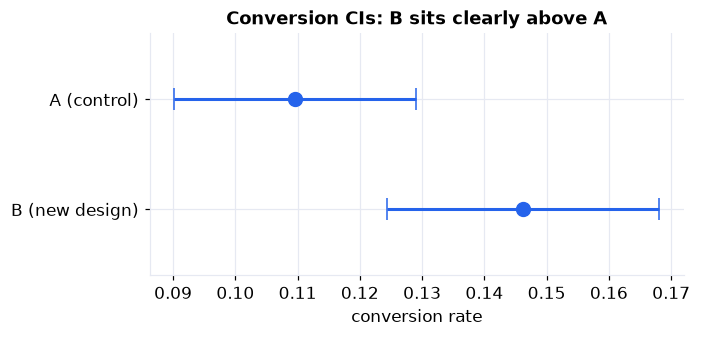

In [7]:
fig,ax=plt.subplots(figsize=(6.5,3.2))
ax.errorbar([pA,pB],[1,0],xerr=[[pA-loA,pB-loB],[hiA-pA,hiB-pB]],fmt="o",color=BLUE,capsize=7,lw=2,ms=9)
ax.set_yticks([1,0]); ax.set_yticklabels(["A (control)","B (new design)"]); ax.set_ylim(-0.6,1.6)
ax.set_xlabel("conversion rate"); ax.set_title("Conversion CIs: B sits clearly above A")
plt.tight_layout(); plt.show()

Variant A converts at about <strong>11.0%</strong> and B at <strong>14.6%</strong>, a lift of roughly <strong>+3.7 points</strong> whose 95% interval runs about <strong>[+0.8, +6.6] points</strong>, entirely above zero. The new design is a genuine improvement, not noise, so the team ships B. Notice the two individual CIs barely overlap; the proper test is always the CI on the <em>difference</em>, not eyeballing two separate intervals.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Proportions &amp; differences</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">A proportion CI is p-hat +/- z*sqrt(p-hat(1-p-hat)/n), valid under the success-failure condition. For a difference, combine the two standard errors and check whether the CI excludes 0. On a real A/B test, B converts 14.6% vs A 11.0%, a +3.7 point lift with a 95% CI of about [+0.8, +6.6] that clears zero, so B wins.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>